-------------------------------
-------------------------------
# Proyecto 2 - Minería de Datos (CC3074)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Javier Linares - 231135
* Cristian Túnchez - 231359

-------------------------------
-------------------------------

-------------------------------
**Semana 2:** Preparación de datos + Modelos base  

-------------------------------

In [1]:
# ======================
# Importación de librerías
# ======================
# pandas / numpy: manipulación numérica y de tablas

import pandas as pd

# Cargar el dataset
df = pd.read_csv("Datos.csv")

# Vista rápida, valida que se cargó correctamente y revisa columnas/valores iniciales
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [2]:
# ======================
# Preprocesamiento
# ======================


# Eliminar columna irrelevante
df = df.drop(columns=["Sample code number"]) # Es un ID, no aporta información predicitiva

In [3]:
# ======================
# Manejo de Valores faltantes
# ======================

# "?" se convirtió en NaN al cargar el dataset, ahora se pueden eliminar filas con valores faltantes
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')
df = df.dropna()

In [4]:
# ======================
# Se separan variables
# ======================

X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
# Escalamiento de características 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# ======================
# Train-test split
# ======================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 80% entrenamiento, 20% prueba, random_state para reproducibilidad

-------------------------------
**MODELOS BASE:** (Regresión Logística, Árbol de Decisión, Random Forest) 

-------------------------------

In [7]:
# ======================
# Regresión Logística
# ======================
# Es base, simple y funciona bien en clasificación binaria.

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [8]:
# ======================
# Árbol de Decisión
# ======================
# Bueno para interpretar relaciones

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [9]:
# ======================
# Random Forest
# ======================
# Mejora árboles (menos overfitting)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

-------------------------------
**MÉTRICAS** 

-------------------------------

In [10]:
# ======================
# Función para no repetir código 
# ======================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluar_modelo(y_test, y_pred, nombre):
    print(f"--- {nombre} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label=4))
    print("Recall:", recall_score(y_test, y_pred, pos_label=4))
    print("F1 Score:", f1_score(y_test, y_pred, pos_label=4))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\n")

In [11]:
# ======================
# Evaluar todos los modelos
# ======================

evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
evaluar_modelo(y_test, y_pred_tree, "Árbol de Decisión")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

--- Regresión Logística ---
Accuracy: 0.9562043795620438
Precision: 0.9814814814814815
Recall: 0.9137931034482759
F1 Score: 0.9464285714285714
Matriz de confusión:
 [[78  1]
 [ 5 53]]


--- Árbol de Decisión ---
Accuracy: 0.9343065693430657
Precision: 0.9622641509433962
Recall: 0.8793103448275862
F1 Score: 0.918918918918919
Matriz de confusión:
 [[77  2]
 [ 7 51]]


--- Random Forest ---
Accuracy: 0.948905109489051
Precision: 0.9811320754716981
Recall: 0.896551724137931
F1 Score: 0.9369369369369369
Matriz de confusión:
 [[78  1]
 [ 6 52]]




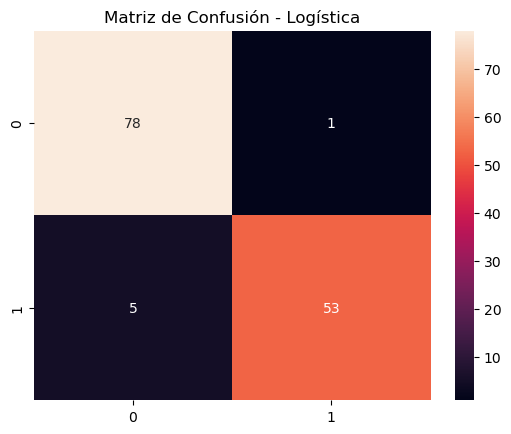

In [ ]:
# ======================
# Visualización de la matriz de confusión - Regresión Logística
# ======================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión - Logística")
plt.show()

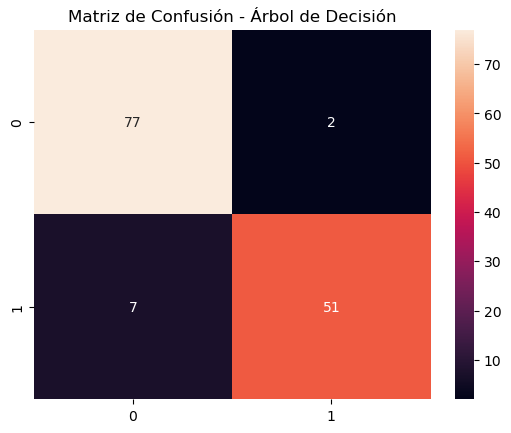

In [13]:
# ======================
# Visualización de la matriz de confusión - Árbol de Decisión
# ======================

cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

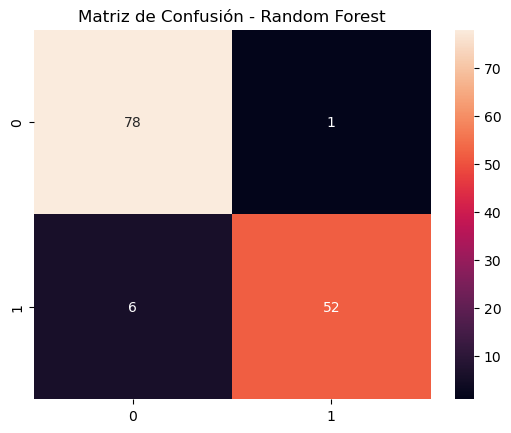

In [14]:
# ======================
# Visualización de la matriz de confusión - Random Forest
# ======================

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de Confusión - Random Forest")
plt.show()